In [33]:
import sys
import os
sys.path.append(os.path.abspath('..'))

import torch
import numpy as np

from dataset.dataset import Dataset
from utils.config import load_config
from utils.builder import build_trainer

# FCN

In [34]:
config_path = "../configs/fcn_full.yaml"

In [35]:
config = load_config(config_path)
data_path = "../"+config["data"]["data_path"]

torch.manual_seed(config["experiment"]["seed"])
np.random.seed(config["experiment"]["seed"])

dataset = Dataset(data_path, "G", config["data"]["batch_size"], use_tabular=config["data"]["use_tabular"], tabular_features=config["data"]["tabular_features"])
train_loader, val_loader, test_loader = dataset.get_loaders()

dataset_f = Dataset(data_path, "F", config["data"]["batch_size"])
_, val_loader_f, test_loader_f = dataset_f.get_loaders()

dataset_m = Dataset(data_path, "M", config["data"]["batch_size"])       
_, val_loader_m, test_loader_m = dataset_m.get_loaders()

In [36]:
trainer = build_trainer(config)
trainer.load_checkpoint()

## Testing with simillar threshold

In [37]:
best_thr = trainer.choose_threshold(val_loader)

Best threshold: 0.404
Sensitivity: 0.902
Specificity: 0.816
AUC: 0.954
Accuracy: 0.858


In [38]:
print("\n===== ALL =====")
out = trainer.test(test_loader, best_thr)


===== ALL =====
           TEST RESULTS
  Threshold         : 0.404
  AUC               : 0.9380
  Accuracy          : 0.8572
  Sensitivity       : 0.8882  (recall on MI)
  Specificity       : 0.8260  (recall on NORM)
  Precision         : 0.8375
  F1 Score          : 0.8621
  Confusion Matrix
               Pred NORM   Pred MI
  True NORM  :     622        131
  True MI    :      85        675
              precision    recall  f1-score   support

        NORM       0.88      0.83      0.85       753
          MI       0.84      0.89      0.86       760

    accuracy                           0.86      1513
   macro avg       0.86      0.86      0.86      1513
weighted avg       0.86      0.86      0.86      1513



In [39]:
print("\n===== FEMALE =====")
out = trainer.test(test_loader_f, best_thr)


===== FEMALE =====
           TEST RESULTS
  Threshold         : 0.404
  AUC               : 0.9462
  Accuracy          : 0.8529
  Sensitivity       : 0.8959  (recall on MI)
  Specificity       : 0.8060  (recall on NORM)
  Precision         : 0.8342
  F1 Score          : 0.8639
  Confusion Matrix
               Pred NORM   Pred MI
  True NORM  :     270         65
  True MI    :      38        327
              precision    recall  f1-score   support

        NORM       0.88      0.81      0.84       335
          MI       0.83      0.90      0.86       365

    accuracy                           0.85       700
   macro avg       0.86      0.85      0.85       700
weighted avg       0.85      0.85      0.85       700



In [40]:
print("\n===== MALE =====")
out = trainer.test(test_loader_m, best_thr)


===== MALE =====
           TEST RESULTS
  Threshold         : 0.404
  AUC               : 0.9527
  Accuracy          : 0.8795
  Sensitivity       : 0.8960  (recall on MI)
  Specificity       : 0.8631  (recall on NORM)
  Precision         : 0.8660
  F1 Score          : 0.8808
  Confusion Matrix
               Pred NORM   Pred MI
  True NORM  :     353         56
  True MI    :      42        362
              precision    recall  f1-score   support

        NORM       0.89      0.86      0.88       409
          MI       0.87      0.90      0.88       404

    accuracy                           0.88       813
   macro avg       0.88      0.88      0.88       813
weighted avg       0.88      0.88      0.88       813



## Choosing best threshold separately for G, M and F

In [41]:
best_thr = trainer.choose_threshold(val_loader)

print("\n===== ALL =====")
out = trainer.test(test_loader, best_thr)

Best threshold: 0.404
Sensitivity: 0.907
Specificity: 0.841
AUC: 0.953
Accuracy: 0.872

===== ALL =====
           TEST RESULTS
  Threshold         : 0.404
  AUC               : 0.9423
  Accuracy          : 0.8553
  Sensitivity       : 0.8813  (recall on MI)
  Specificity       : 0.8296  (recall on NORM)
  Precision         : 0.8357
  F1 Score          : 0.8579
  Confusion Matrix
               Pred NORM   Pred MI
  True NORM  :     633        130
  True MI    :      89        661
              precision    recall  f1-score   support

        NORM       0.88      0.83      0.85       763
          MI       0.84      0.88      0.86       750

    accuracy                           0.86      1513
   macro avg       0.86      0.86      0.86      1513
weighted avg       0.86      0.86      0.86      1513



In [42]:
best_thr = trainer.choose_threshold(val_loader_f)

print("\n===== FEMALE =====")
out = trainer.test(test_loader_f, best_thr)

Best threshold: 0.327
Sensitivity: 0.916
Specificity: 0.839
AUC: 0.958
Accuracy: 0.874

===== FEMALE =====
           TEST RESULTS
  Threshold         : 0.327
  AUC               : 0.9260
  Accuracy          : 0.8057
  Sensitivity       : 0.9026  (recall on MI)
  Specificity       : 0.6906  (recall on NORM)
  Precision         : 0.7760
  F1 Score          : 0.8345
  Confusion Matrix
               Pred NORM   Pred MI
  True NORM  :     221         99
  True MI    :      37        343
              precision    recall  f1-score   support

        NORM       0.86      0.69      0.76       320
          MI       0.78      0.90      0.83       380

    accuracy                           0.81       700
   macro avg       0.82      0.80      0.80       700
weighted avg       0.81      0.81      0.80       700



In [43]:
best_thr = trainer.choose_threshold(val_loader_m)

print("\n===== MALE =====")
out = trainer.test(test_loader_m, best_thr)

Best threshold: 0.455
Sensitivity: 0.905
Specificity: 0.858
AUC: 0.955
Accuracy: 0.882

===== MALE =====
           TEST RESULTS
  Threshold         : 0.455
  AUC               : 0.9553
  Accuracy          : 0.8795
  Sensitivity       : 0.8886  (recall on MI)
  Specificity       : 0.8691  (recall on NORM)
  Precision         : 0.8845
  F1 Score          : 0.8866
  Confusion Matrix
               Pred NORM   Pred MI
  True NORM  :     332         50
  True MI    :      48        383
              precision    recall  f1-score   support

        NORM       0.87      0.87      0.87       382
          MI       0.88      0.89      0.89       431

    accuracy                           0.88       813
   macro avg       0.88      0.88      0.88       813
weighted avg       0.88      0.88      0.88       813



### ROC curves

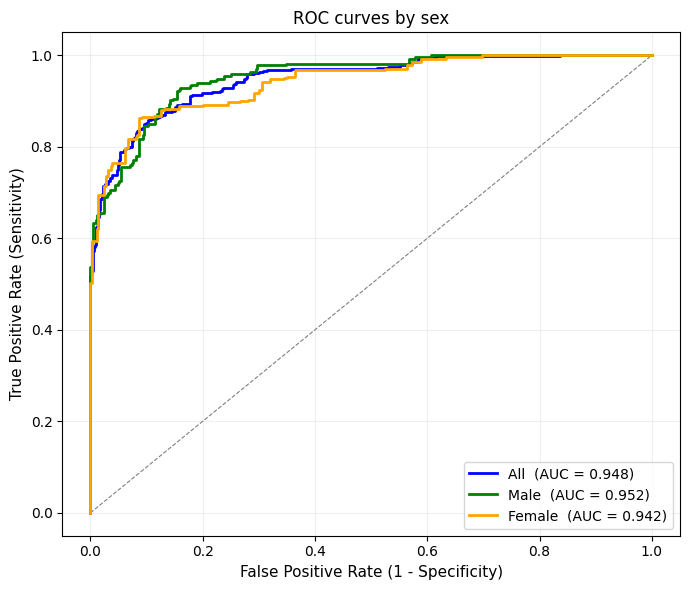

In [ ]:
from utils.metrics import plot_roc_curves

plot_roc_curves(
    trainer,
    loaders_dict={
        'All':    test_loader,
        'Male':   test_loader_m,
        'Female': test_loader_f,
    }
)